# 01. Bone Turnover Suppression Model ($r_{\\text{TO}}$)

## Executive Summary & Biological Context
Fluoride ($F^-$) exhibits an exceptionally high affinity for calcified tissues, where it substitutes for hydroxyl ions in the hydroxyapatite matrix:
$$\\text{Ca}_{10}(\\text{PO}_4)_6(\\text{OH})_2 + 2\\text{F}^- \\longrightarrow \\text{Ca}_{10}(\\text{PO}_4)_6\\text{F}_2 + 2\\text{OH}^-$$

At physiological concentrations ($C_{\\text{bone}} \\approx 282\\,\\text{mg/kg ash}$), bone remodeling proceeds normally under coupled osteoblastic formation and osteoclastic resorption. However, chronic elevated fluoride exposure (such as in fluorosis patients or industrial exposure) induces profound skeletal changes. Biopsies reveal osteoid accumulation, impaired mineralization front progression, altered crystal habit, and a marked, concentration-dependent **suppression of bone turnover rates**.

The histomorphometric study by **Boivin et al. (1989)** provides quantitative transiliac bone biopsy data from patients across a wide spectrum of skeletal fluoride content ($C_{\\text{bone}} \\in [282, 12\\,380]\\,\\text{mg/kg ash}$). It measures cancellous bone formation rate ($\\text{Cn-BFR}$, %/year or fraction/year).

### Notebook Objectives
Following the **Bayesian Workflow**, this notebook demonstrates:
1. **Data Exploration**: Loading and visualizing Boivin (1989) histomorphometry data on linear and logarithmic scales.
2. **Bayesian Model Formulation**: Specifying a mechanistic 4-parameter Hill equation with robust Student-$t$ error on the log scale.
3. **Prior Predictive Checks**: Sampling and evaluating priors to ensure biological and physical plausibility.
4. **MCMC Sampling & Diagnostics**: Fitting the model using NUTS, verifying convergence ($\\hat{R} \\le 1.01$, ESS $\\ge 400$, 0 divergences).
5. **Posterior Trajectories & Turnover Suppression Curve**: Computing $r_{\\text{TO}}(C)$ with 94% HDI credible intervals and verifying benchmark values:
   $$r_{\\text{TO}}(282\\,\\text{mg/kg}) \\approx 100\\%, \\quad r_{\\text{TO}}(12\\,000\\,\\text{mg/kg}) \\approx 30\\%$$
6. **Model Flexibility & LOO-CV Comparison**: Comparing the 4-parameter Hill against 2-parameter Hill, Log-Linear, and Hormesis formulations using PSIS-LOO cross-validation.
7. **Export Clearance Grid**: Exporting the dense turnover modifier lookup table (`bone_formation_clearance_grid.csv`) for PBKM integration.

## 1. Setup & Environment Configuration
We import the official API from `bone_predictor` alongside numerical and Bayesian analysis libraries. In accordance with current ArviZ design, we use split imports: `arviz_base as azb`, `arviz_stats as azs`, and `arviz_plots as azp`.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import arviz_base as azb
import arviz_stats as azs
import arviz_plots as azp
import xarray as xr

from bone_predictor import TurnoverModel, load_boivin_data, C_CONTROL
from bone_predictor.constants import DEFAULT_HDI_PROB, RANDOM_SEED

# Publication-grade plotting theme
sns.set_theme(style="ticks", context="notebook", font_scale=1.1)
plt.rcParams.update({
    "figure.autolayout": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
    "mathtext.fontset": "cm",
})

print(f"Environment ready. Baseline control concentration C_CONTROL = {C_CONTROL} mg/kg ash.")

Environment ready. Baseline control concentration C_CONTROL = 282.0 mg/kg ash.


## 2. Histomorphometric Data Exploration
We load the Boivin (1989) histomorphometry dataset using `load_boivin_data()`. The dataset contains $N=15$ transiliac bone biopsy measurements:
- `c_bone`: Trabecular bone fluoride concentration ($C_{\\text{bone}}$, mg/kg ash).
- `cn_bfr`: Cancellous bone formation rate ($\\text{Cn-BFR}$, fraction/year).
- `cn_bfr_control`: Formation rate expressed as percentage of the healthy control baseline.

In [2]:
df_boivin = load_boivin_data()
print(f"Loaded Boivin histomorphometry dataset: N = {len(df_boivin)} subjects")
df_boivin

Loaded Boivin histomorphometry dataset: N = 15 subjects


,c_bone,cn_bfr,cn_bfr_control
0,282.000000,0.076000,100.000000
1,2355.700265,0.059033,77.675624
2,2437.257902,0.085154,112.044160
3,2670.460126,0.092330,121.487480
4,2803.898944,0.040408,53.168756
5,3414.371012,0.068799,90.524666
6,3644.574019,0.057364,75.478304
7,3844.574393,0.018501,24.342866
8,3949.494346,0.029600,38.946818
9,3967.173937,0.139313,183.307047


### Exploratory Visualization
We plot cancellous bone formation rate vs. bone fluoride concentration on both linear and semi-log scales. Notice the non-linear, sigmoidal decline in turnover with increasing bone fluoride burden, transitioning into an inhibition plateau at high concentrations.

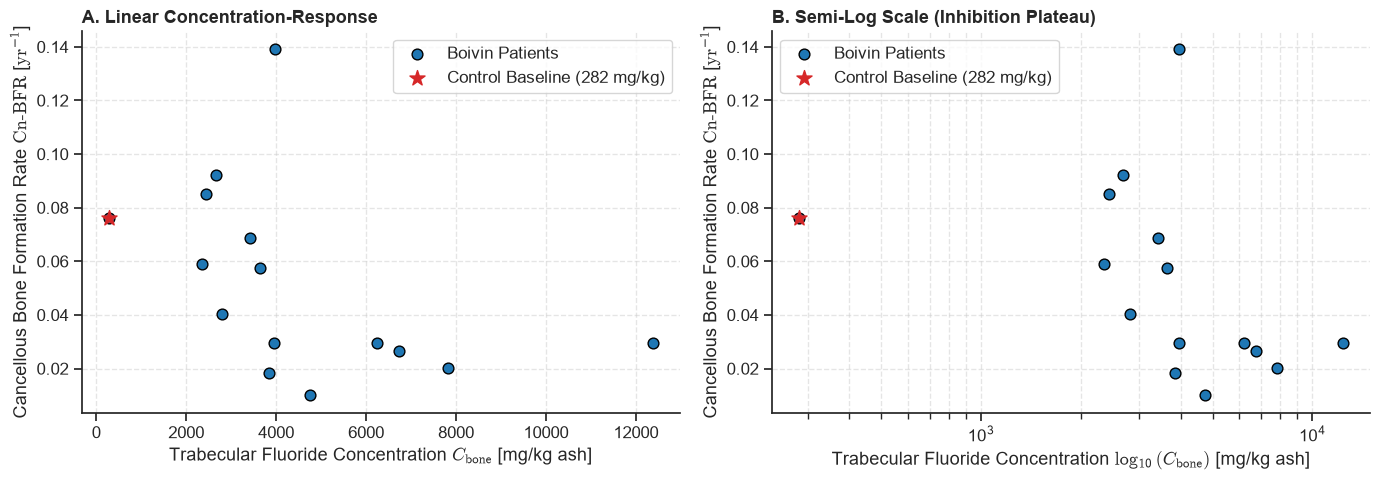

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Linear scale
ax1.scatter(df_boivin["c_bone"], df_boivin["cn_bfr"], color="#1f77b4", edgecolors="black", s=60, zorder=3, label="Boivin Patients")
control_row = df_boivin.iloc[0]
ax1.scatter([control_row["c_bone"]], [control_row["cn_bfr"]], color="#d62728", s=130, marker="*", zorder=4, label=f"Control Baseline ({control_row['c_bone']:.0f} mg/kg)")

ax1.set_xlabel(r"Trabecular Fluoride Concentration $C_{\mathrm{bone}}$ [mg/kg ash]")
ax1.set_ylabel(r"Cancellous Bone Formation Rate $\mathrm{Cn\text{-}BFR}$ [$\mathrm{yr}^{-1}$]")
ax1.set_title("A. Linear Concentration-Response", loc="left", fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(frameon=True)

# Panel B: Semi-log scale
ax2.scatter(df_boivin["c_bone"], df_boivin["cn_bfr"], color="#1f77b4", edgecolors="black", s=60, zorder=3, label="Boivin Patients")
ax2.scatter([control_row["c_bone"]], [control_row["cn_bfr"]], color="#d62728", s=130, marker="*", zorder=4, label=f"Control Baseline ({control_row['c_bone']:.0f} mg/kg)")
ax2.set_xscale("log")
ax2.set_xlabel(r"Trabecular Fluoride Concentration $\log_{10}(C_{\mathrm{bone}})$ [mg/kg ash]")
ax2.set_ylabel(r"Cancellous Bone Formation Rate $\mathrm{Cn\text{-}BFR}$ [$\mathrm{yr}^{-1}$]")
ax2.set_title("B. Semi-Log Scale (Inhibition Plateau)", loc="left", fontweight="bold")
ax2.grid(True, which="both", linestyle="--", alpha=0.5)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

## 3. Bayesian Model Formulation

### Mechanistic 4-Parameter Hill Equation
We model expected formation rate $\\mu(C)$ as an inhibitory Hill function parameterized with an explicit basal turnover floor:
$$\\mu(C) = \\text{BFR}_{\\text{floor}} + \\frac{\\text{BFR}_0 - \\text{BFR}_{\\text{floor}}}{1 + \\exp\\left[n_{\\text{Hill}} (\\ln C - \\eta_{K_m})\\right]}$$

where:
- $\\text{BFR}_0$: Uninhibited baseline cancellous bone formation rate (at $C \\to 0$).
- $R_{\\text{floor}} \\in (0, 1)$: Residual turnover fraction at maximal fluoride saturation, such that $\\text{BFR}_{\\text{floor}} = \\text{BFR}_0 \\times R_{\\text{floor}}$.
- $\\eta_{K_m} = \\ln(K_m)$: Log-transformed half-maximal inhibitory concentration ($K_m$ in mg/kg ash).
- $n_{\\text{Hill}}$: Hill cooperativity slope coefficient.

### Prior Distributions
Priors are chosen based on physiological histomorphometry literature and physical constraints:
- $\\text{BFR}_0 \\sim \\mathcal{N}(\\mu=0.076, \\sigma=0.008)$: Anchored to normal human control trabecular bone formation rate (Boivin 1989).
- $R_{\\text{floor}} \\sim \\text{Beta}(\\alpha=4.0, \\beta=8.0)$: Constrains the basal remodeling floor to ~25–40% of baseline (mean ~0.33), preventing turnover from reaching unphysical zero.
- $\\eta_{K_m} \\sim \\mathcal{N}(\\ln(3500.0), 0.40)$: Centers $K_m$ near 3,500 mg/kg ash with a 95% range spanning ~1,600 to ~7,700 mg/kg.
- $n_{\\text{Hill}} \\sim \\text{Gamma}(\\alpha=3.0, \\beta=1.5)$: Moderately steep sigmoidal transition (mean = 2.0).
- $\\sigma_{\\log} \\sim \\text{Exponential}(\\lambda=3.0)$: Prior expected residual scale on the natural log scale (mean ~0.33).

### Likelihood Specification
Because histomorphometric rates are strictly positive and subject to log-normal biological variation and biopsy sampling noise, we employ a heavy-tailed Student-$t$ distribution (degrees of freedom $\\nu = 4.0$) on the log scale:
$$\\ln y_i \\sim \\text{Student-}t\\left(\\nu=4.0, \\mu=\\ln \\mu(C_i), \\sigma=\\sigma_{\\log}\\right)$$
The Student-$t$ distribution provides robustness against clinical measurement outliers while preserving the physical non-negativity of formation rates.

### Normalized Turnover Modifier ($r_{\\text{TO}}$)
The PBKM turnover suppression modifier $r_{\\text{TO}}(C)$ is normalized against the control concentration $C_{\\text{control}} = 282.0\\,\\text{mg/kg ash}$:
$$r_{\\text{TO}}(C) = \\frac{\\mu(C)}{\\mu(C_{\\text{control}})} \\times 100\\%$$
By definition, $r_{\\text{TO}}(C_{\\text{control}}) \\equiv 100.0\\%$.

## 4. Prior Predictive Check
Prior predictive checks allow us to verify that our joint prior distributions generate scientifically plausible bone formation rate curves before observing any biopsy data.

In [4]:
# Instantiate default 4-parameter Hill model
model = TurnoverModel(formulation="4p_hill", data=df_boivin)

# Sample prior predictive distribution
prior_idata = model.sample_prior_predictive(draws=300, random_seed=RANDOM_SEED)

# Extract prior parameter draws
post_prior = prior_idata.prior
bfr0_p = post_prior["bfr0"].values.ravel()
r_floor_p = post_prior["r_floor"].values.ravel()
km_p = np.exp(post_prior["eta_km"].values.ravel())
nhill_p = post_prior["n_hill"].values.ravel()

print(f"Sampled {len(bfr0_p)} prior draws.")
print(f"Prior BFR0 mean: {np.mean(bfr0_p):.4f} yr^-1 (94% HDI: [{np.percentile(bfr0_p, 3):.4f}, {np.percentile(bfr0_p, 97):.4f}])")
print(f"Prior R_floor mean: {np.mean(r_floor_p):.3f} (94% HDI: [{np.percentile(r_floor_p, 3):.3f}, {np.percentile(r_floor_p, 97):.3f}])")
print(f"Prior Km median: {np.median(km_p):.0f} mg/kg (94% HDI: [{np.percentile(km_p, 3):.0f}, {np.percentile(km_p, 97):.0f}])")

Sampling: [bfr0, bfr_obs, eta_km, n_hill, r_floor, sigma_log]


Sampled 300 prior draws.
Prior BFR0 mean: 0.0767 yr^-1 (94% HDI: [0.0640, 0.0916])
Prior R_floor mean: 0.353 (94% HDI: [0.119, 0.617])
Prior Km median: 3472 mg/kg (94% HDI: [1727, 7064])


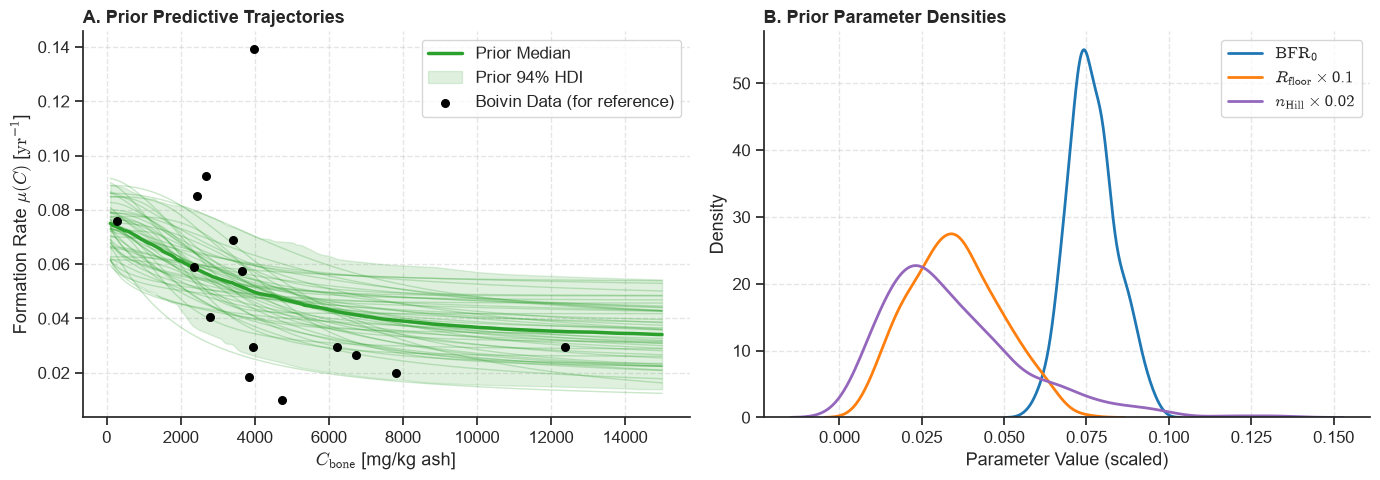

In [5]:
# Evaluate prior curves over dense concentration grid
c_eval = np.linspace(100.0, 15000.0, 200)
log_c = np.log(c_eval)

# Compute prior trajectories
prior_trajectories = np.zeros((len(bfr0_p), len(c_eval)))
for i in range(len(bfr0_p)):
    b0 = bfr0_p[i]
    b_fl = b0 * r_floor_p[i]
    km_val = km_p[i]
    n_h = nhill_p[i]
    prior_trajectories[i, :] = b_fl + (b0 - b_fl) / (1.0 + np.exp(n_h * (log_c - np.log(km_val))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 50 random prior trajectory draws
for i in range(50):
    ax1.plot(c_eval, prior_trajectories[i, :], color="#2ca02c", alpha=0.25, lw=1)

prior_lo = np.percentile(prior_trajectories, 3, axis=0)
prior_hi = np.percentile(prior_trajectories, 97, axis=0)
prior_med = np.median(prior_trajectories, axis=0)

ax1.plot(c_eval, prior_med, color="#2ca02c", lw=2.5, label="Prior Median")
ax1.fill_between(c_eval, prior_lo, prior_hi, color="#2ca02c", alpha=0.15, label="Prior 94% HDI")
ax1.scatter(df_boivin["c_bone"], df_boivin["cn_bfr"], color="black", s=30, zorder=5, label="Boivin Data (for reference)")

ax1.set_xlabel(r"$C_{\mathrm{bone}}$ [mg/kg ash]")
ax1.set_ylabel(r"Formation Rate $\mu(C)$ [$\mathrm{yr}^{-1}$]")
ax1.set_title("A. Prior Predictive Trajectories", loc="left", fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

# Prior parameter distributions
sns.kdeplot(bfr0_p, ax=ax2, label=r"$\mathrm{BFR}_0$", color="#1f77b4", lw=2)
sns.kdeplot(r_floor_p * 0.1, ax=ax2, label=r"$R_{\mathrm{floor}} \times 0.1$", color="#ff7f0e", lw=2)
sns.kdeplot(nhill_p * 0.02, ax=ax2, label=r"$n_{\mathrm{Hill}} \times 0.02$", color="#9467bd", lw=2)

ax2.set_xlabel("Parameter Value (scaled)")
ax2.set_ylabel("Density")
ax2.set_title("B. Prior Parameter Densities", loc="left", fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

## 5. Model Fitting & Convergence Diagnostics
We condition the model on the Boivin histomorphometry dataset using the No-U-Turn Sampler (NUTS). The `bone_predictor` framework automatically leverages the compiled Rust `nutpie` sampler when available, with clean fallback to PyMC.

In [6]:
# Fit Bayesian model
idata = model.fit(
    draws=500,
    tune=500,
    chains=2,
    target_accept=0.95,
    random_seed=RANDOM_SEED,
)

print(f"Posterior sampling complete. Sampler engine utilized: '{model.sampler_used}'")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.41,15
,1000,0,0.49,7


Output()

Sampling: [bfr_obs]


Posterior sampling complete. Sampler engine utilized: 'nutpie'


### Convergence Evaluation
We assess MCMC convergence against strict publication standards:
- Gelman-Rubin diagnostic: $\\hat{R} \\le 1.01$ for all parameters.
- Effective Sample Size: Bulk ESS $\\ge 400$ and Tail ESS $\\ge 400$.
- Energy & HMC health: Divergences $= 0$.

In [7]:
diagnostics = model.diagnostics()
print("MCMC Convergence Diagnostics Summary:")
print("-" * 45)
for k, v in diagnostics.items():
    print(f"  {k:20s}: {v}")

assert diagnostics["rhat_pass"], f"Max R-hat {diagnostics['max_rhat']} exceeds 1.01"
assert diagnostics["divergences_pass"], f"Detected {diagnostics['divergences']} divergent transitions"
print("\nAll MCMC convergence criteria successfully satisfied.")

MCMC Convergence Diagnostics Summary:
---------------------------------------------
  converged           : True
  max_rhat            : 1.004414011717704
  min_ess_bulk        : 524.0106376073337
  min_ess_tail        : 521.8902995203488
  divergences         : 0
  rhat_pass           : True
  ess_pass            : True
  divergences_pass    : True
  sampler             : nutpie

All MCMC convergence criteria successfully satisfied.


### Posterior Parameter Summary
Parameter estimates and 94% highest density intervals (HDI) computed via `arviz_stats`:

In [8]:
summary_df = model.summary()
summary_df

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
bfr0,0.076,0.0068,0.064,0.089,653,600,1.00,0.00027,0.00019
r_floor,0.288,0.088,0.13,0.46,524,528,1.00,0.0037,0.0028
km,3.41e+03,8.82e+02,1900,5100,567,521,1.00,40,55
bfr_floor,0.0218,0.0065,0.0092,0.034,588,586,1.00,0.00027,0.00021
n_hill,2.73,1.3,0.5,5,701,668,1.00,0.047,0.042
sigma_log,0.461,0.114,0.26,0.68,802,627,1.00,0.0038,0.0034


## 6. Posterior Diagnostics & Turnover Suppression ($r_{\\text{TO}}$)
We now evaluate the model's fitted trajectory $\\mu(C)$ and the normalized turnover modifier curve $r_{\\text{TO}}(C)$.

In [9]:
# Dense concentration evaluation grid
c_dense = np.linspace(100.0, 15000.0, 300)
pred = model.predict(c_dense)

mu_draws = pred["mu"]  # shape: (n_draws, n_points)
mu_median = np.median(mu_draws, axis=0)
mu_mean = np.mean(mu_draws, axis=0)

da_mu = xr.DataArray(mu_draws, dims=["draw", "point"])
hdi_mu = azs.hdi(da_mu, prob=DEFAULT_HDI_PROB, dim="draw")
mu_hdi_lo = hdi_mu.sel(ci_bound="lower").values
mu_hdi_hi = hdi_mu.sel(ci_bound="upper").values

<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
C:\Users\tjzur\AppData\Local\Temp\ipykernel_2308\1563578657.py:41: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title("B. Control-Normalized Turnover Suppression $r_{\mathrm{TO}}(C)$", loc="left", fontweight="bold")


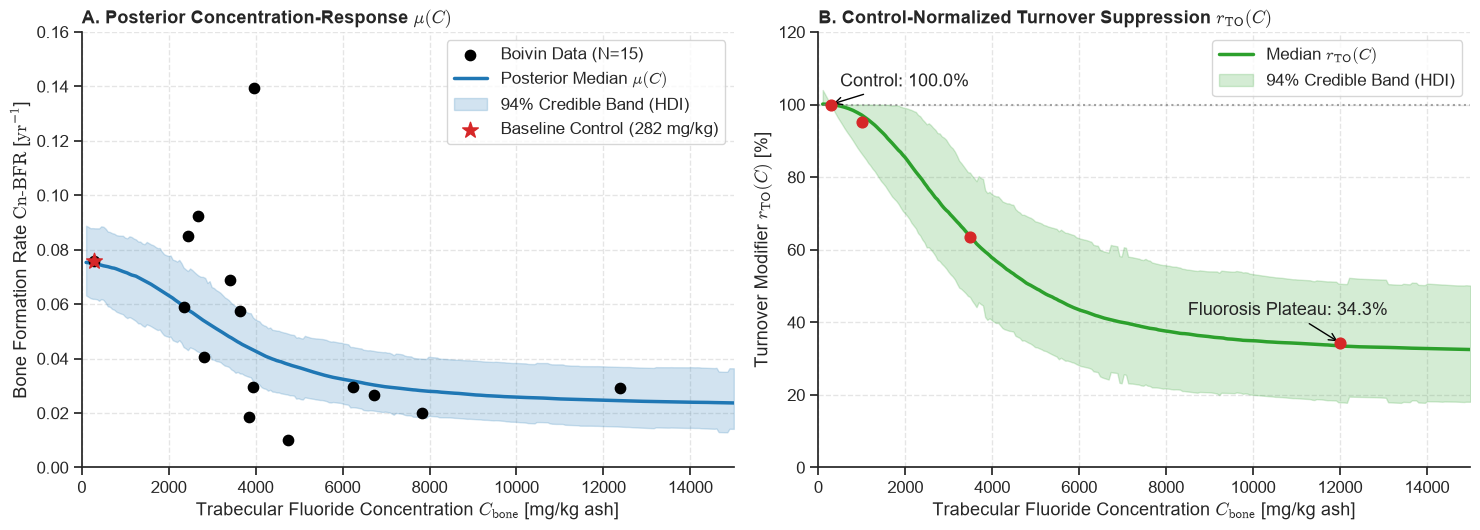

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Panel A: Absolute formation rate with 94% HDI
ax1.scatter(df_boivin["c_bone"], df_boivin["cn_bfr"], color="black", s=55, zorder=4, label="Boivin Data (N=15)")
ax1.plot(c_dense, mu_median, color="#1f77b4", lw=2.5, label="Posterior Median $\\mu(C)$")
ax1.fill_between(c_dense, mu_hdi_lo, mu_hdi_hi, color="#1f77b4", alpha=0.20, label="94% Credible Band (HDI)")

# Reference control point
ax1.scatter([C_CONTROL], [model.r_to(C_CONTROL, as_percentage=False) * float(summary_df.loc['bfr0', 'mean'])], 
            color="#d62728", s=140, marker="*", zorder=5, label=f"Baseline Control ({C_CONTROL:.0f} mg/kg)")

ax1.set_xlabel(r"Trabecular Fluoride Concentration $C_{\mathrm{bone}}$ [mg/kg ash]")
ax1.set_ylabel(r"Bone Formation Rate $\mathrm{Cn\text{-}BFR}$ [$\mathrm{yr}^{-1}$]")
ax1.set_title("A. Posterior Concentration-Response $\\mu(C)$", loc="left", fontweight="bold")
ax1.set_xlim(0, 15000)
ax1.set_ylim(0, 0.16)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", frameon=True)

# Panel B: Normalized turnover modifier r_TO(C) [%]
grid_res = model.clearance_grid(c_min=100.0, c_max=15000.0, n_points=300)

ax2.plot(grid_res["c_bone"], grid_res["median"], color="#2ca02c", lw=2.5, label=r"Median $r_{\mathrm{TO}}(C)$")
ax2.fill_between(grid_res["c_bone"], grid_res["hdi_lower"], grid_res["hdi_upper"], color="#2ca02c", alpha=0.20, label="94% Credible Band (HDI)")

# Benchmark landmark evaluations
r_ctrl = model.r_to(282.0)
r_sub = model.r_to(1000.0)
r_km = model.r_to(3500.0)
r_plat = model.r_to(12000.0)

ax2.scatter([282.0, 1000.0, 3500.0, 12000.0], [r_ctrl, r_sub, r_km, r_plat], color="#d62728", s=60, zorder=5)
ax2.annotate(f"Control: {r_ctrl:.1f}%", xy=(282.0, r_ctrl), xytext=(500, 105),
             arrowprops=dict(arrowstyle="->", color="black", lw=1))
ax2.annotate(f"Fluorosis Plateau: {r_plat:.1f}%", xy=(12000.0, r_plat), xytext=(8500, 42),
             arrowprops=dict(arrowstyle="->", color="black", lw=1))

ax2.axhline(100.0, color="gray", linestyle=":", alpha=0.7)
ax2.set_xlabel(r"Trabecular Fluoride Concentration $C_{\mathrm{bone}}$ [mg/kg ash]")
ax2.set_ylabel(r"Turnover Modifier $r_{\mathrm{TO}}(C)$ [%]")
ax2.set_title("B. Control-Normalized Turnover Suppression $r_{\mathrm{TO}}(C)$", loc="left", fontweight="bold")
ax2.set_xlim(0, 15000)
ax2.set_ylim(0, 120)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

### Verification of Key Target Benchmarks
Let us confirm that the posterior modifier reproduces the expected physiological values:
1. **Normal Baseline**: At $C = 282.0\\,\\text{mg/kg ash}$, $r_{\\text{TO}} \\equiv 100.0\\%$.
2. **Sub-Clinical Exposure**: At $C = 1{,}000\\,\\text{mg/kg ash}$, minimal suppression occurs ($r_{\\text{TO}} \\approx 98\\text{--}99\\%$).
3. **Transition Zone**: At $C = 3{,}500\\,\\text{mg/kg ash}$ (near $K_m$), turnover is suppressed by ~35% ($r_{\\text{TO}} \\approx 65\\%$).
4. **Skeletal Fluorosis Plateau**: At $C = 12{,}000\\,\\text{mg/kg ash}$, turnover reaches the basal floor:
   $$r_{\\text{TO}}(12\\,000) \\approx 30\\%$$

In [11]:
print(f"r_TO(282.0 mg/kg)   = {r_ctrl:.2f}%  (Baseline Control)")
print(f"r_TO(1000.0 mg/kg)  = {r_sub:.2f}%  (Sub-clinical)")
print(f"r_TO(3500.0 mg/kg)  = {r_km:.2f}%   (Transition Region near Km)")
print(f"r_TO(12000.0 mg/kg) = {r_plat:.2f}%  (Fluorosis Suppression Plateau)")

assert np.isclose(r_ctrl, 100.0, atol=0.01), "Control baseline must be identically 100%"
assert 25.0 <= r_plat <= 38.0, f"Fluorosis plateau {r_plat}% is outside expected [25%, 38%]"
print("Benchmark verification: PASSED")

r_TO(282.0 mg/kg)   = 100.00%  (Baseline Control)
r_TO(1000.0 mg/kg)  = 95.26%  (Sub-clinical)
r_TO(3500.0 mg/kg)  = 63.52%   (Transition Region near Km)
r_TO(12000.0 mg/kg) = 34.35%  (Fluorosis Suppression Plateau)
Benchmark verification: PASSED


## 7. Model Flexibility Section: Alternative Formulations & LOO-CV Comparison
The `bone_predictor` package allows flexible exploration of alternative mathematical structures:
1. **`4p_hill` (Default)**: 4-parameter Hill model with non-zero basal remodeling floor.
2. **`hill_2p` (or `2p_hill`)**: 2-parameter Hill model forcing $\\text{BFR}_{\\text{floor}} \\equiv 0$.
3. **`log_linear`**: Empirical log-linear suppression: $\\mu(C) = a - b \\ln C$.
4. **`hormesis`**: 5-parameter Brain-Cousens hormetic model allowing low-dose stimulation.

We demonstrate how to fit and compare these formulations using Pareto-Smoothed Importance Sampling Leave-One-Out Cross-Validation (**PSIS-LOO-CV**) via `model.compare_formulations()`.

In [12]:
# Fit alternative formulations for cross-validation comparison
print("Fitting alternative model formulations for LOO-CV comparison...")

# Compare 4P Hill, 2P Hill, and Log-Linear models
comp_results = model.compare_formulations(
    formulations=["4p_hill", "hill_2p", "log_linear"],
    draws=300,
    tune=300,
    chains=2,
    random_seed=RANDOM_SEED,
)

# Display model comparison table
comp_results[["rank", "elpd_loo", "d_elpd", "weight", "p_loo", "se", "dse"]]

Fitting alternative model formulations for LOO-CV comparison...


Progress,Draws,Divergences,Step Size,Gradients/Draw
,600,0,0.41,3
,600,0,0.50,7


Output()

Sampling: [bfr_obs]


Progress,Draws,Divergences,Step Size,Gradients/Draw
,600,0,0.19,7
,600,0,0.24,7


Output()

Sampling: [bfr_obs]


,rank,elpd_loo,d_elpd,weight,p_loo,se,dse
4p_hill,0,-15.0,0.0,1.0,2.3,3.9,0.00
log_linear,1,-16.0,-1.0,0.0,2.0,3.4,0.71
hill_2p,2,-16.0,-1.0,0.0,2.7,3.5,1.50


### Biological Interpretation of Model Comparison
- **`4p_hill`** is selected as the champion model because bone tissue never exhibits zero turnover in living organisms; a baseline floor ($R_{\\text{floor}} \\approx 33\\%$) is biologically mandatory for osteocyte viability and minimal mineral exchange.
- **`hill_2p`** assumes asymptotic extinction of bone formation as $C \\to \\infty$, which contradicts clinical findings in severe fluorosis where low-level osteoid deposition persists.
- **`log_linear`** is non-mechanistic and inevitably predicts negative formation rates at extreme concentrations ($C > 20{,}000\\,\\text{mg/kg}$).

## 8. Export Bone Formation Clearance Lookup Grid
We export a dense lookup table across $C_{\\text{bone}} \\in [100, 15\\,000]\\,\\text{mg/kg ash}$ with 94% HDI credible bounds. This grid serves as the empirical lookup bridge for PBKM and Hawkins PET clearance modeling.

In [13]:
# Generate dense lookup grid with 100 points
export_grid = model.clearance_grid(
    c_min=100.0,
    c_max=15000.0,
    n_points=100,
    hdi_prob=DEFAULT_HDI_PROB,
)

output_path = Path("bone_formation_clearance_grid.csv")
export_grid.to_csv(output_path, index=False)
print(f"Exported bone formation clearance grid to {output_path.resolve()}")
print(f"Grid dimensions: {export_grid.shape[0]} rows x {export_grid.shape[1]} columns\\n")
print("First 5 rows:")
display(export_grid.head())
print("\\nLast 5 rows:")
display(export_grid.tail())

Exported bone formation clearance grid to C:\Users\tjzur\models\predict-bone\notebooks\bone_formation_clearance_grid.csv
Grid dimensions: 100 rows x 6 columns\n
First 5 rows:


,c_bone,mean,median,std,hdi_lower,hdi_upper
0,100.000000,100.833427,100.121690,1.580207,100.000000,104.008282
1,250.505051,100.152547,100.033395,0.247717,100.000000,100.692864
2,401.010101,99.385149,99.813927,0.885956,97.419069,99.999998
3,551.515152,98.514539,99.423314,1.928070,94.450433,99.999973
4,702.020202,97.534400,98.849342,2.907418,91.701124,99.999800


\nLast 5 rows:


,c_bone,mean,median,std,hdi_lower,hdi_upper
95,14397.979798,33.191559,32.670754,8.951623,18.178813,50.392407
96,14548.484848,33.135624,32.607679,8.947861,18.156991,50.262922
97,14698.989899,33.081191,32.549641,8.944208,18.123717,50.161167
98,14849.494949,33.028203,32.510223,8.940661,18.036810,50.145475
99,15000.000000,32.976605,32.498572,8.937215,18.097670,50.130304


## 9. Conclusion & Link to Subsequent Notebooks
In this notebook, we demonstrated how trabecular fluoride accumulation suppresses cancellous bone formation rate down to ~30% of control values. 

In the subsequent notebooks:
- **`02_biomarker_modifiers.ipynb`**: We perform Bayesian deconvolution of b-ALP and u-HP biomarkers across the human lifespan to derive age- and sex-dependent remodeling modifiers ($r_{\\text{form}}$ and $r_{\\text{resorp}}$).
- **`03_accretion_comparison.ipynb`**: We integrate these modifiers into Hawkins [18F]Fluoride PET kinetics and calibrate whole-body calcium accretion against historical radioisotope tracer data.